In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

Loading the dataset to pandas data frame (df)

In [2]:
df = pd.read_csv(r"H:\Diabetes_predictor\Data\diabetes.csv")

Inspect the dataset 


In [9]:
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
print(df.describe()) # To undertstand the data distribution

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

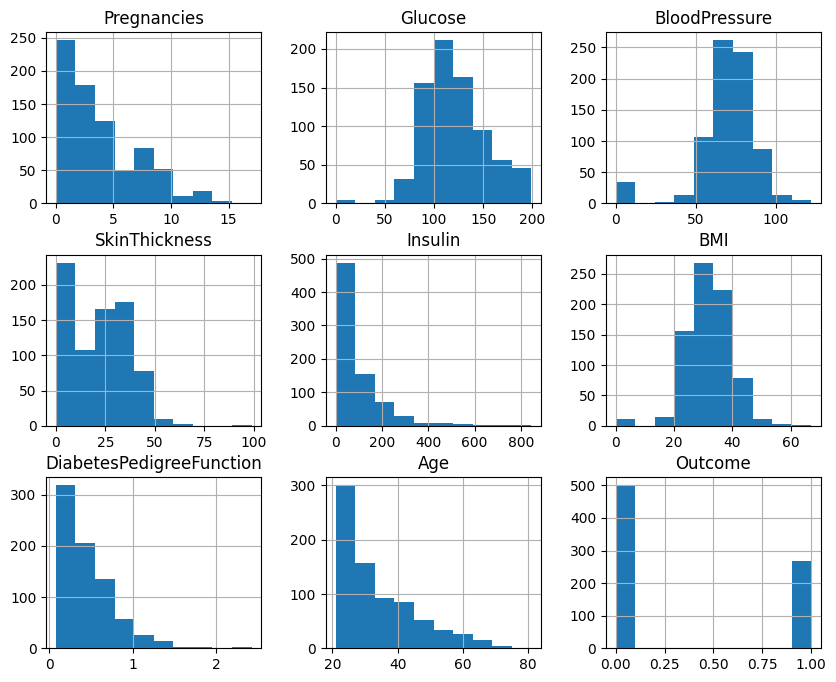

In [12]:
df.hist(figsize=(10, 8))

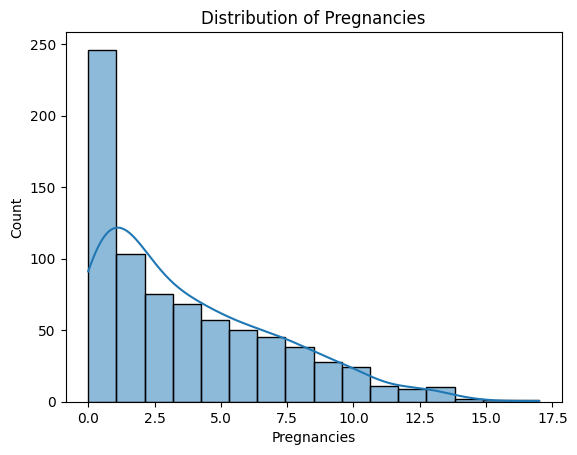

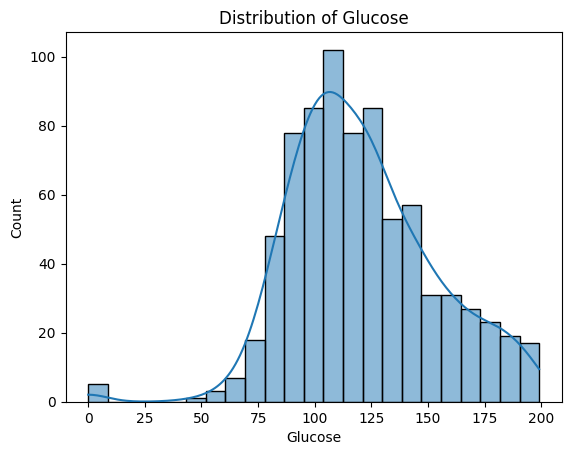

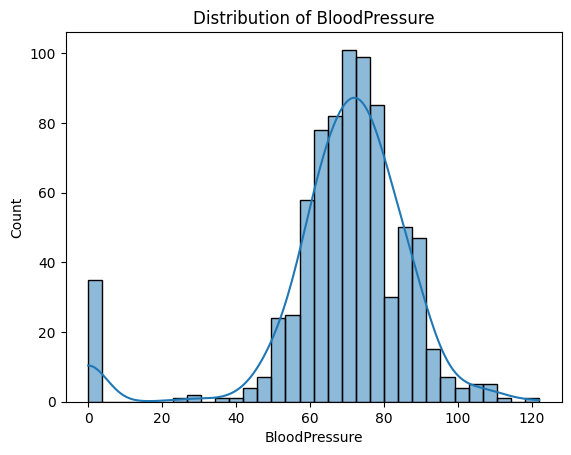

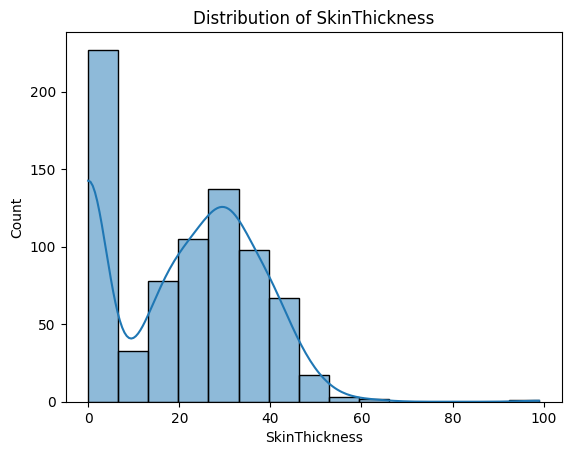

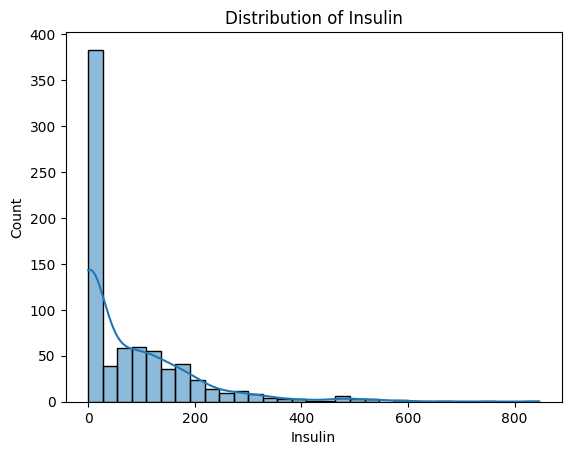

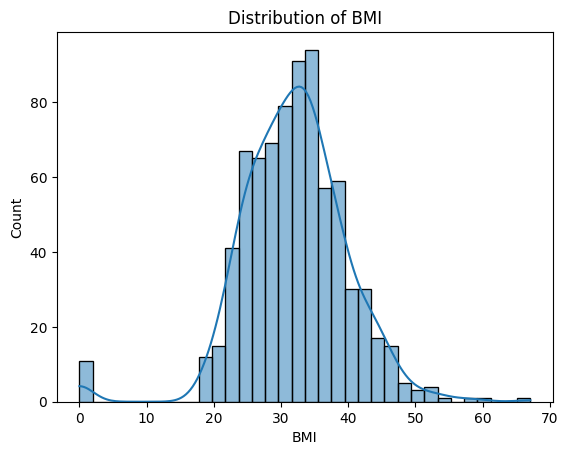

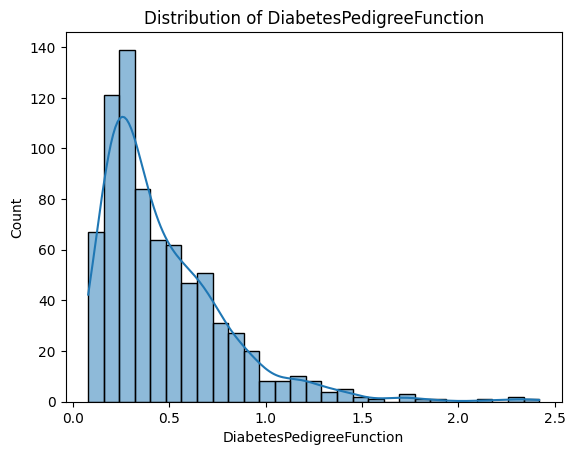

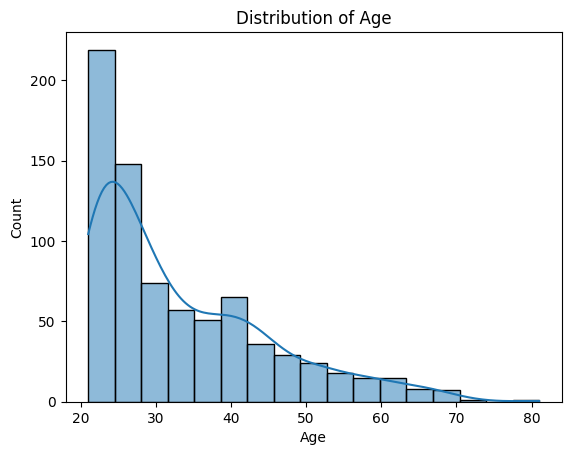

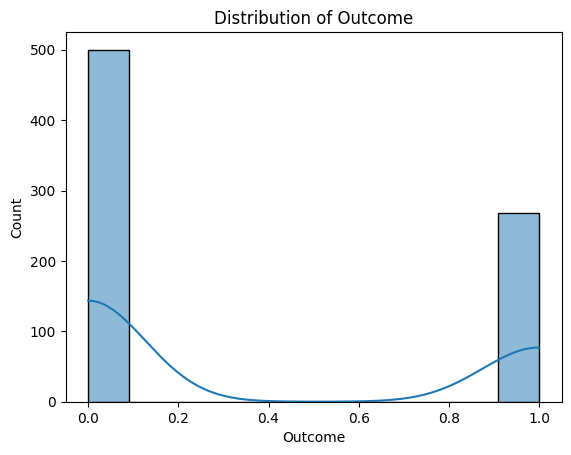

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

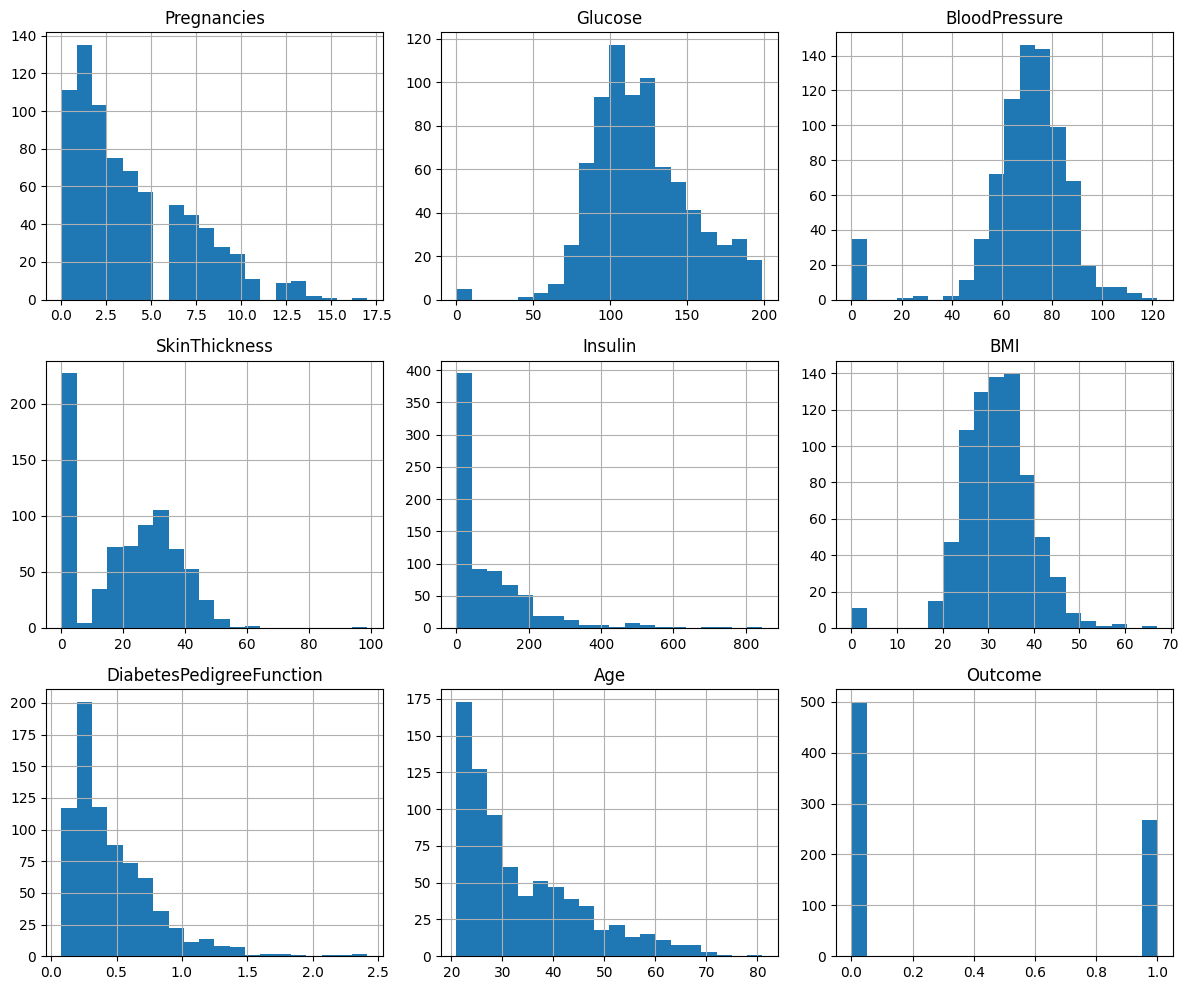

In [14]:
num_cols = df.select_dtypes(include=['number']).columns

df[num_cols].hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

In [5]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [6]:
print(df.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [7]:
zero_counts = (X == 0).sum()
print(zero_counts)

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


In [ ]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X[cols_with_zeros] = X[cols_with_zeros].replace(0, np.nan)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
import pandas as pd

X_numeric = X.select_dtypes(include=['float64', 'int64']).copy()

# Scale features to 0-1
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_numeric), columns=X_numeric.columns)

# KNN imputation
imputer = KNNImputer(n_neighbors=5)
X_imputed_scaled = pd.DataFrame(imputer.fit_transform(X_scaled), columns=X_scaled.columns)

# Inverse scale back to original range
X_imputed = pd.DataFrame(scaler.inverse_transform(X_imputed_scaled), columns=X_numeric.columns)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import joblib


# -----------------------------
# 2. Handle class imbalance using SMOTE
# -----------------------------
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_imputed_scaled, y)

# -----------------------------
# 3. Define models to evaluate
# -----------------------------
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42)
}

# -----------------------------
# 4. Stratified K-Fold Cross Validation
# -----------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
roc_auc_results = {}

plt.figure(figsize=(12,8))

for name, model in models.items():
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0,1,100)
    
    for train_index, test_index in skf.split(X_res, y_res):
        X_train, X_test = X_res.iloc[train_index], X_res.iloc[test_index]
        y_train, y_test = y_res.iloc[train_index], y_res.iloc[test_index]
        
        # Fit model
        model.fit(X_train, y_train)
        # Predict probabilities
        y_proba = model.predict_proba(X_test)[:,1]
        
        # Compute ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = roc_auc_score(y_test, y_proba)
        aucs.append(roc_auc)
        
        # Interpolate TPR
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0
    
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = np.mean(aucs)
    roc_auc_results[name] = mean_auc
    
    plt.plot(mean_fpr, mean_tpr, label=f'{name} (AUC = {mean_auc:.2f})')

plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Classification Models')
plt.legend(loc='lower right')
plt.show()

# -----------------------------
# 5. Select best model
# -----------------------------
best_model_name = max(roc_auc_results, key=roc_auc_results.get)
best_model = models[best_model_name]
print(f"Best Model: {best_model_name} with ROC-AUC = {roc_auc_results[best_model_name]:.4f}")

# Train best model on full resampled dataset
best_model.fit(X_res, y_res)

# -----------------------------
# 6. Save the best model
# -----------------------------
joblib.dump(best_model, r'H:\Diabetes_predictor\models\best_classification_model.pkl')
print("Best model saved as 'best_classification_model.pkl'")


ModuleNotFoundError: No module named 'imblearn'